In [1]:
import os
if os.getcwd()[-11:] == "exploration":
    os.chdir('..')
import data.involcan.pull

### Find stations of interest

In [2]:
import pandas as pd

files = pd.read_csv("data/involcan/metadata/available_files.csv")

In [3]:
# from datetime import datetime
starttime = pd.Timestamp('2021-09-12', tz='UTC')
endtime = pd.Timestamp('2021-09-26', tz='UTC')


files['start_time'] = pd.to_datetime(files['start_time'], utc=True)
files['end_time'] = pd.to_datetime(files['end_time'], utc=True)


eruption_files = files[(files['start_time']==starttime) | (files['end_time']==endtime) ]
eruption_stations = pd.unique(eruption_files['station']).tolist()

In [4]:
print(f"There were {len(eruption_stations)} measuring during the eruption")
print(f"They were: \n {eruption_stations}")

There were 18 measuring during the eruption
They were: 
 ['PGAR', 'PBBA', 'PPMA', 'PMLU', 'PLPI', 'PTAB', 'PCOR', 'PA03', 'PA00', 'PA05', 'PA09', 'PA01', 'PA04', 'PA02', 'PA08', 'PA06', 'PA07', 'PSAB']


In [5]:
stations = pd.read_csv("data/involcan/metadata/stations_all.dat", sep=r"\s+",names=["station", "lat", "lon", "height"])
stations_lp = stations[
    ((stations['lat']<28.871164) & (stations['lat']>28.437932)) &
    ((stations['lon']<-17.666590) & (stations['lon']>-18.039439))
]


In [6]:
from shapely.geometry import Point, Polygon

polygon_coords = [[-18.043671,28.436091],[-18.043671,28.879552],
                  [-17.704468,28.879552],[-17.704468,28.436091],]
polygon = Polygon(polygon_coords)

point = Point(-17.888489,28.694202)
polygon.contains(point)

def is_inside(row, polygon):
    point = Point(row['lon'], row['lat'])  # Importante: (x, y) = (lon, lat)
    return polygon.contains(point)

stations_lp = stations[stations.apply(is_inside, axis=1, args = (polygon,))]

### Download the files of interest

In [7]:
from datetime import datetime, timedelta
starttime = datetime(2021, 9, 15)
endtime = datetime(2021, 9, 20)
# endtime = datetime(2021, 12, 14)
data_path = "/SCRATCH/TIC270/gsus/data/involcan/mseed/eruption/"
data_path = "data/involcan/mseed/"
channels = ["HHE", "HHN", "HHZ"]
# channels = ["HHE"]
stations = eruption_stations

# data.involcan.pull.download_files(starttime, endtime, stations, channels, data_path, user='seiscomp', key_path="~/.ssh/id_ed25519", verbose=True);

#### Discarded stations:
- PGAR: File missing data
- PBBA: File missing data
- PA03: Missing data before the 18th of september
- PA00: Missing data before the 19th of september
- PA05: Missing data in the period of interest
- PA09: Missing data in the period of interest
- PA01: Missing data in the period of interest
- PA04: Missing data in the period of interest
- PA02: Missing data in the period of interest
- PA08: Missing data in the period of interest
- PA06: Missing data in the period of interest
- PA07: Missing data in the period of interest
- PSAB: No data in the period of interest


### Analyze the data

In [8]:
import obspy
from obspy.core import UTCDateTime
import numpy as np


ST = []
stations = ['PPMA', 'PMLU', 'PLPI', 'PTAB','PCOR']
# stations = ["PPMA"]
channels = ["HHE", "HHN", "HHZ"]
# channels = ["HHE"]
# stations = ['PPMA', 'PLPI']

station_ids = [eruption_stations.index(element) for element in stations if element in eruption_stations]

for station_id in station_ids:
    print(f"Reading 2021 data for station {eruption_stations[station_id]}...")
    st = obspy.read(f"{data_path}/C7.{eruption_stations[station_id]}.*.*.*.2021.*",
                    starttime=UTCDateTime(starttime), endtime=UTCDateTime(endtime))
    st.merge()
    # st.plot();
    ST.append(st)



Reading 2021 data for station PPMA...
Reading 2021 data for station PMLU...
Reading 2021 data for station PLPI...
Reading 2021 data for station PTAB...
Reading 2021 data for station PCOR...


In [9]:
# import obspy
# from obspy.core import UTCDateTime
# from datetime import datetime, timedelta
# starttime = datetime(2021, 9, 15)
# endtime = datetime(2021, 9, 20)
# data_path = "/SCRATCH/TIC270/gsus/data/involcan/mseed/eruption/"
# st = obspy.read(f"{data_path}/C7.PLPI.*.*.*.2021.*",
#                 starttime=UTCDateTime(starttime), endtime=UTCDateTime(endtime))
# st.merge()

# st.trim(UTCDateTime(starttime+timedelta(minutes=10)), UTCDateTime(endtime-timedelta(minutes=10)))

In [10]:
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates

# # Guarda la figura devuelta por plot()
# fig = st.plot(size=(1000, 900), equal_scale=True, show=False,
#               normalize = True, color="#2731F5")

# fontsize = 20
# tick_fontsize = 20

# # Cambia todo el texto visible
# for text in fig.findobj(match=plt.Text):
#     text.set_fontsize(fontsize)

# for ax in fig.axes:

#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
#     # Cambia tamaño de ticks
#     ax.tick_params(axis='x', labelsize=tick_fontsize)
#     ax.tick_params(axis='y', labelsize=tick_fontsize-1)

#     # Títulos y etiquetas de eje
#     ax.set_title(ax.get_title(), fontsize=fontsize)
#     ax.set_xlabel(ax.get_xlabel(), fontsize=fontsize)
#     ax.set_ylabel(ax.get_ylabel(), fontsize=fontsize)

#     # Leyendas
#     legend = ax.get_legend()
#     if legend:
#         for text in legend.get_texts():
#             text.set_fontsize(fontsize)


# # Guardar figura
# fig.savefig("a.png")


#### Eliminate calibration pulses

In [11]:
pulses = []
# PPMA pulses:
pulses.append([UTCDateTime(datetime(2021,9,16,16,33,30)), UTCDateTime(datetime(2021,9,16,16, 36,30))])
# st.plot(starttime=UTCDateTime(datetime(2021,9,16,16, 33,30)), endtime=UTCDateTime(datetime(2021,9,16,16, 36,30)));

pulses.append([UTCDateTime(datetime(2021,9,15,6, 51,0)), UTCDateTime(datetime(2021,9,15,6,54,30))])
# st.plot(starttime=UTCDateTime(datetime(2021,9,15,6, 51,0)), endtime=UTCDateTime(datetime(2021,9,15,6,54,30)));



#### Analyze frequencies with MESA

In [12]:
from msa.feature_extraction import features
from msa.visualization import plot

In [13]:
sr = st[0].stats.sampling_rate

window_length = 20 # s
window_samples = int(window_length*sr)
# shift = window_length*1000 #s
shift = 3600 #s
hop = int(shift*sr)

M = len(station_ids)
N = len(channels)
times = [[[] for _ in range(N)] for _ in range(M)]
freqs = [[[] for _ in range(N)] for _ in range(M)]
Sxxs  = [[[] for _ in range(N)] for _ in range(M)]

for i, station_id in reversed(list(enumerate(station_ids))):
    for j, channel in reversed(list(enumerate(channels))):

        signal = ST[i][j].data
        
        if np.ma.is_masked(signal):
            times[i][j] = np.ones_like(time[1:])
            freqs[i][j] = np.ones_like(freq)
            Sxxs[i][j] = np.ones_like(Sxx[:,1:])
        else:
            time, freq, Sxx = features.spectrogram(signal, sr, window_samples, hop, "blackman", "zeros", "linear",)
            times[i][j] = time[1:]
            freqs[i][j] = freq
            Sxxs[i][j]  = Sxx[:,1:]
        # print(Sxx.shape, time.shape, freq.shape, i, j)


Sxxs = np.array(Sxxs)
freqs = np.array(freqs)
times = np.array(times)

In [14]:
Sxxs[1,1], Sxxs[1,0]

(array([[3.11355770e+08, 5.86488284e+06, 8.14636847e+08, ...,
         5.40717749e+10, 6.33581847e+07, 7.45719434e+11],
        [6.20617084e+09, 1.27518845e+09, 1.80112327e+09, ...,
         2.06128068e+10, 2.95105896e+09, 9.02661349e+11],
        [1.93405255e+09, 9.67504412e+08, 7.19295358e+09, ...,
         1.06904975e+10, 2.54861155e+09, 7.59511231e+11],
        ...,
        [5.56855153e+00, 3.13249503e+00, 8.81987207e+00, ...,
         1.94247404e+01, 1.98298541e+01, 2.63759915e+07],
        [1.03256234e+00, 2.28076002e+01, 2.40417608e+01, ...,
         2.26914064e+01, 2.11362964e+01, 2.63936717e+07],
        [5.46186627e+00, 5.64496430e+01, 8.09044547e+01, ...,
         5.50134062e-02, 5.25731718e+01, 2.64061561e+07]],
       shape=(1001, 120)),
 array([[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1

In [15]:
Sxxs[1, 0] = Sxxs[1, 1]
times[1, 0] = times[1, 1]
freqs[1, 0] = freqs[1, 1]

Sxxs[1, 1] = Sxxs[1, 0]
times[1, 1] = times[1, 0]
freqs[1, 1] = freqs[1, 0]

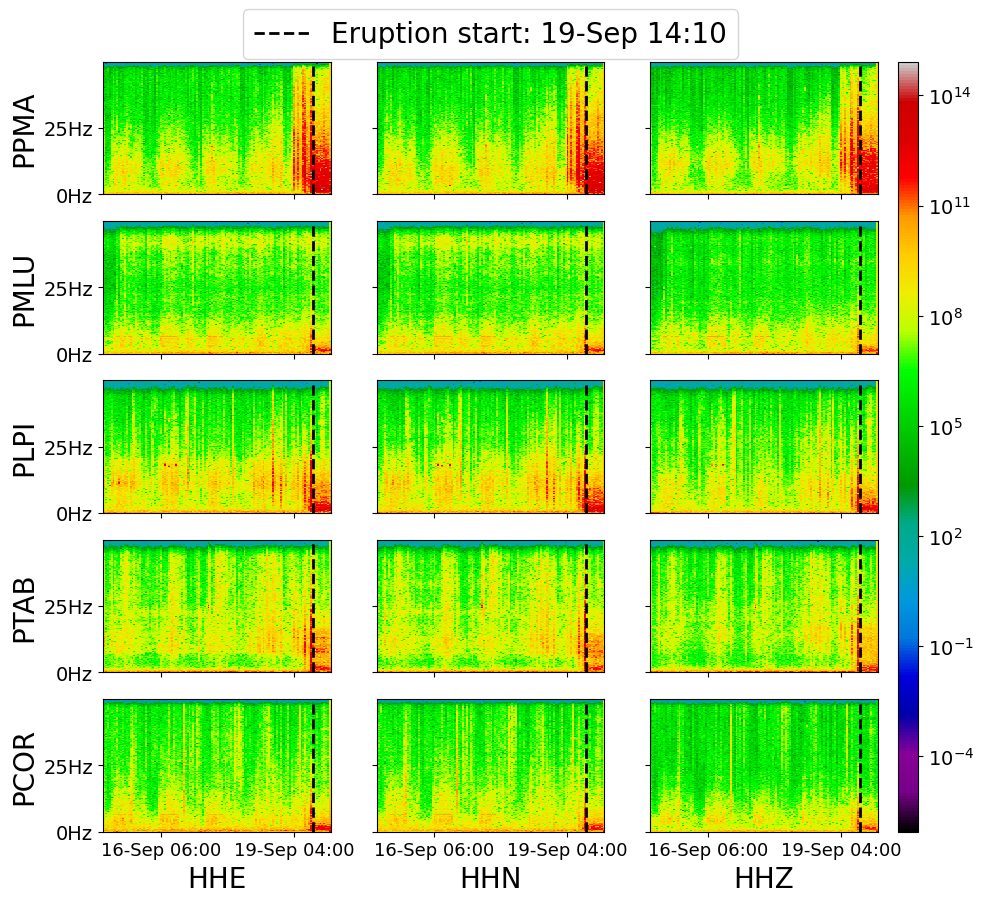

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# timeUTC = np.linspace(starttime, endtime, num= len(times), endpoint=False, dtype='datetime64[s]')#.astype("datetime64[m]")
timeUTC = np.arange(starttime, endtime, timedelta(seconds=shift), dtype='datetime64[s]')#.astype("datetime64[m]")

target_time = np.datetime64(datetime(2021, 9, 19, 14, 10), 'm')
eruption_idx = np.argmin(np.abs(timeUTC - target_time))

fig, ax = plt.subplots(M,N, figsize=(10,10), sharex=True, sharey=True)
if N == 1: ax = ax[:, np.newaxis]
if M == 1: ax = ax[np.newaxis, :]

vmin = np.min(Sxxs)
vmax = np.max(Sxxs)

if type(ax) != np.ndarray: ax = [ax]

skip:int = int(len(times[0][0])/1.7)
start = 30
locs = times[0][0][start::skip]
timeUTC_label = timeUTC[start::skip]
date_formatter = mdates.DateFormatter('%d-%b %H:%M')
formatted_labels = [date_formatter(mdates.date2num(t)) for t in timeUTC_label]

for i, station in enumerate(stations):
    for j, channel in enumerate(channels):
        if j == 0: ax[i, j].set_ylabel(f"{station}", fontsize = 20)
        if i == len(stations)-1: ax[i, j].set_xlabel(f"{channel}", fontsize = 20)
        _,_, mesh = plot.spectrogram(times[i,j], freqs[i,j], Sxxs[i,j], cmap="nipy_spectral",
                                    logscale=True, ax = ax[i,j], vmin=vmin, vmax = vmax, ylim=(0,50));


        ax[i,j].set_xticks(locs[:], labels=formatted_labels[:],fontsize=13);
        ax[i,j].set_yticks([0,25], ['0Hz','25Hz'],fontsize=14);

        ax[i,j].axvline(x=times[i,j,eruption_idx], color='black', linestyle='--', linewidth=2, label='Eruption start: 19-Sep 14:10')


ax[0,1].legend(loc="upper center", bbox_to_anchor=(0.5, 1.5), fontsize = 20, );

tbox = ax[ 0,0].get_position()
bbox = ax[-1,0].get_position()
cax = fig.add_axes([0.92, bbox.y0, 0.02, tbox.y1-bbox.y0])
cbar = fig.colorbar(mesh, cax=cax,)
cbar.ax.tick_params(labelsize=14)


# fig.set_title("Eruption start: 19-Sep 14:10")
# ax.set_ylabel("Frequency (Hz)", fontsize=20)
# fig.text(.05, 0.5, "Frequency (Hz)", ha='center', va='center', rotation=90, fontsize=20);

In [17]:
ST[0][0].data[::1000]

array([ 60950,  60823,  61476, ...,  93661, 147325, 225928],
      shape=(43200,), dtype=int32)

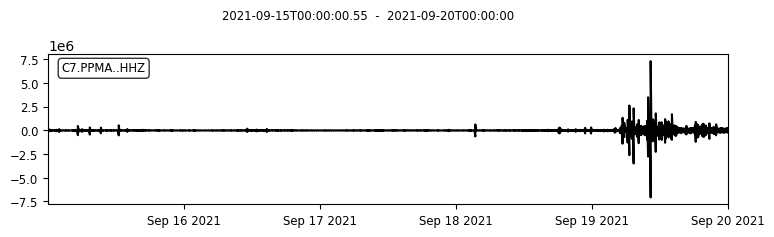

In [18]:
ST[0][2].plot();

In [19]:
times[0][0][-1]

np.float64(432000.0)

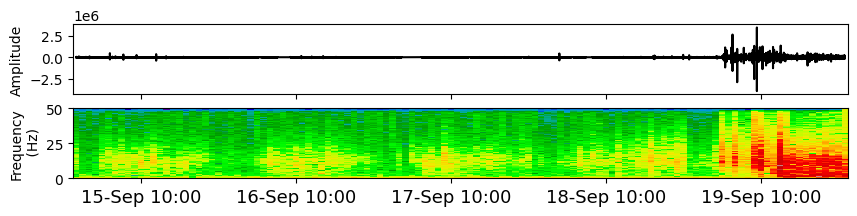

In [20]:
fig, ax = plt.subplots(2,1, figsize=(10,2), sharex=True)

plot.spectrogram(times[0,2], freqs[0,2], Sxxs[0,2], cmap="nipy_spectral",
                                    logscale=True, ax = ax[1], ylim=(0,50));
skip:int = int(len(times[0][0])/5)
start = 10
locs = times[0][0][start::skip]
timeUTC_label = timeUTC[start::skip]
date_formatter = mdates.DateFormatter('%d-%b %H:%M')
formatted_labels = [date_formatter(mdates.date2num(t)) for t in timeUTC_label]
ax[1].set_xticks(locs[:], labels=formatted_labels[:],fontsize=13);


ax[0].set_ylabel("Amplitude")
ax[1].set_ylabel("Frequency\n (Hz)");

time = times[0][2]
signal = ST[0][2].data[::10]
ax[0].plot(
            np.linspace(time[0],time[-1],len(signal)),
            signal, color = "black")


### PCA Visualizations

#### Normalization of the Sxxs tensor

### Preprocessing

In [21]:
Sxxs.shape, type(Sxxs.shape),times.shape
np.mean(Sxxs, 0).shape



Sxxs_norm = Sxxs
# Mean centering
# Sxxs_norm = Sxxs_norm - np.mean(Sxxs_norm, 0)
# Min max scaling
# Sxxs_norm = (Sxxs_norm - np.min(Sxxs_norm, 0)) / (np.max(Sxxs_norm,0) - np.min(Sxxs_norm,0))
# Max scaling
# Sxxs_norm = (Sxxs_norm) / (np.max(np.abs(Sxxs_norm),0))

vmin = np.min(Sxxs_norm)
vmax = np.max(Sxxs_norm)

vmin, vmax


(np.float64(8.82962159654397e-07), np.float64(824282107910092.2))

In [22]:
# Data fusion
X = np.vstack(np.vstack(Sxxs_norm)).T
X.shape


(120, 15015)

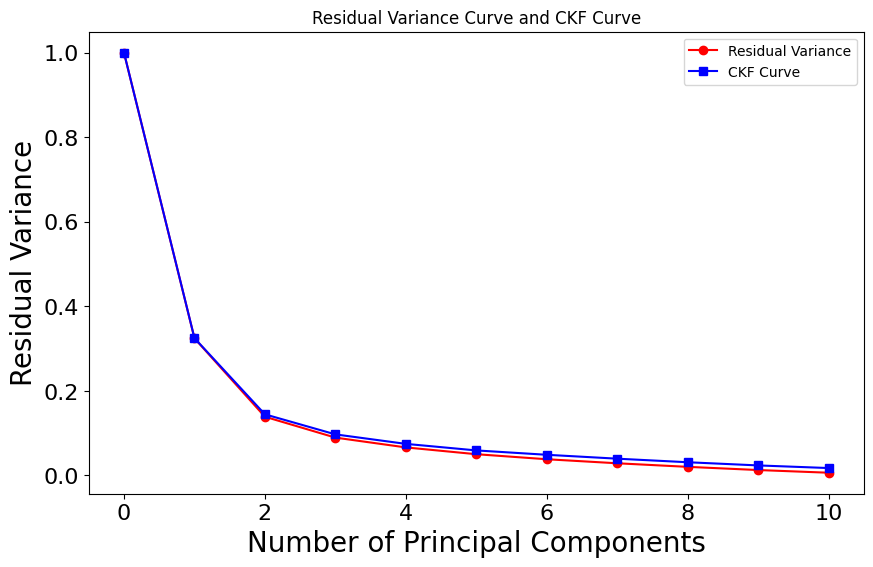

In [23]:
import mspc_pca.plot
mspc_pca.plot.var_pca(X, 10,with_std =False);

In [24]:
# !pip install scikit-learn

In [25]:
scores_label=[]
for date in timeUTC.astype(datetime):
    scores_label.append(date.strftime("%d-%b %H:%M"))

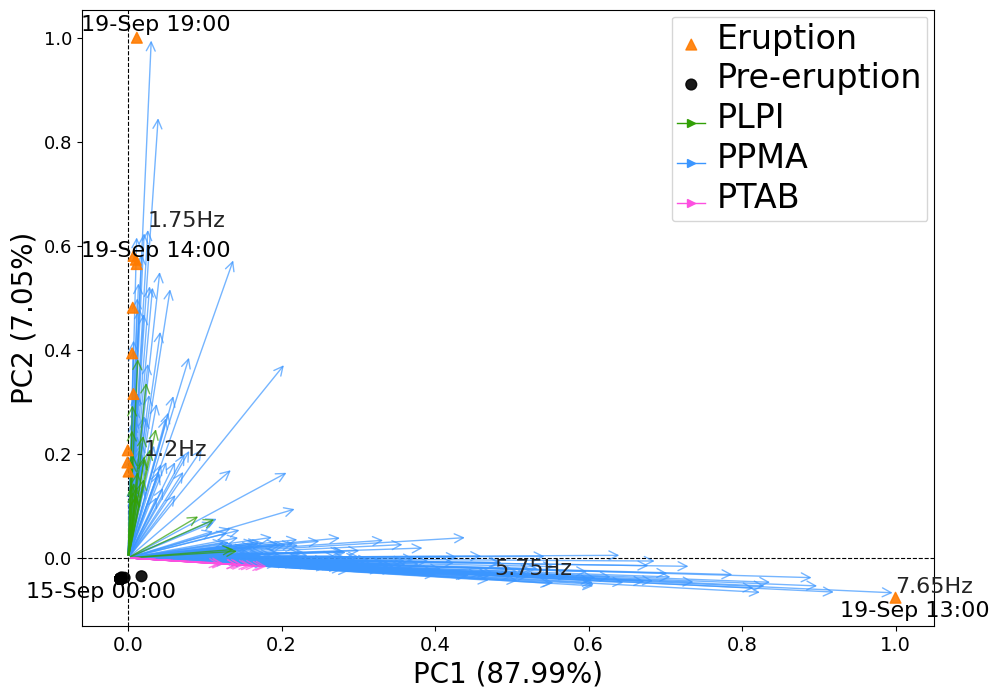

In [26]:
from sklearn.decomposition import PCA

PCs=2
pca = PCA(n_components=PCs)


loadings_label = np.array([f"{round(x, 2)}Hz" for x in freqs[0,0]]*M*N) # Add for several stations 
station_class = np.repeat(stations, freqs[0,0].shape[0]*N)
channel_class = np.repeat(channels, freqs[0,0].shape[0]*M)
# print(channel_class.shape, X.shape)

time_class = np.hstack([np.repeat('Pre-eruption', eruption_idx-1),
                        np.repeat('Eruption', len(times[0,0])-eruption_idx+1)])

markers = np.hstack([np.repeat('o', eruption_idx-1),
                     np.repeat('^', len(times[0,0])-eruption_idx+1)])


from matplotlib.colors import ListedColormap
score_cmap   = ListedColormap(["#FF7B00", "#000000", ])
loading_cmap = ListedColormap(["#32A006", "#3B96FF", "#FD4FE0",  ])


fig, ax = plt.subplots(1,1, figsize=(11,8))
fig, ax, _ = mspc_pca.plot.biplot(X, pca, 1, 2, scores_label, np.array(loadings_label),0.40,
                                time_class.astype(str), station_class.astype(str), loading_percentile = +.015,
                                score_cmap=score_cmap, loading_cmap=loading_cmap, markers=markers,
                                size=60,
                                ax = ax);

fontsize = 16
tick_fontsize = 14
# Cambia todo el texto visible
for text in fig.findobj(match=plt.Text):
    text.set_fontsize(fontsize)

for ax in fig.axes:

    # Cambia tamaño de ticks
    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize-1)

    # Títulos y etiquetas de eje
    ax.set_title(ax.get_title(), fontsize=fontsize)
    ax.set_xlabel(ax.get_xlabel(), fontsize=fontsize+4)
    ax.set_ylabel(ax.get_ylabel(), fontsize=fontsize+4)

    # Leyendas
    legend = ax.get_legend()
    if legend:
        for text in legend.get_texts():
            text.set_fontsize(fontsize+8)

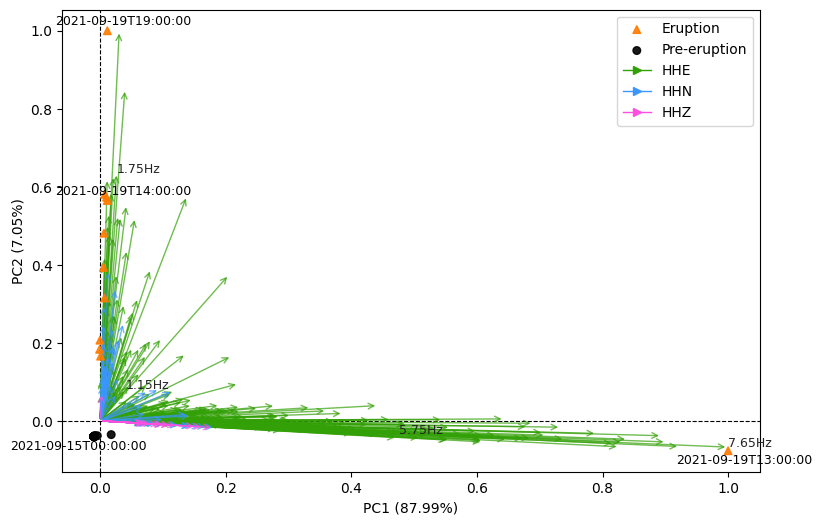

In [27]:
fig, ax = plt.subplots(1,1, figsize=(9,6))
fig, ax, _ = mspc_pca.plot.biplot(X, pca, 1, 2, timeUTC, np.array(loadings_label),0.4,
                                time_class.astype(str), channel_class.astype(str), loading_percentile = +.005,
                                score_cmap=score_cmap, loading_cmap=loading_cmap, markers=markers,
                                size=30,
                                ax = ax);



In [28]:
# Mask to see a specific station:
station = "PPMA"
station_id=0
mask = station_class == station_id

# X=aux
# X_cut = X[:,mask]
# aux = X
# X = X_cut

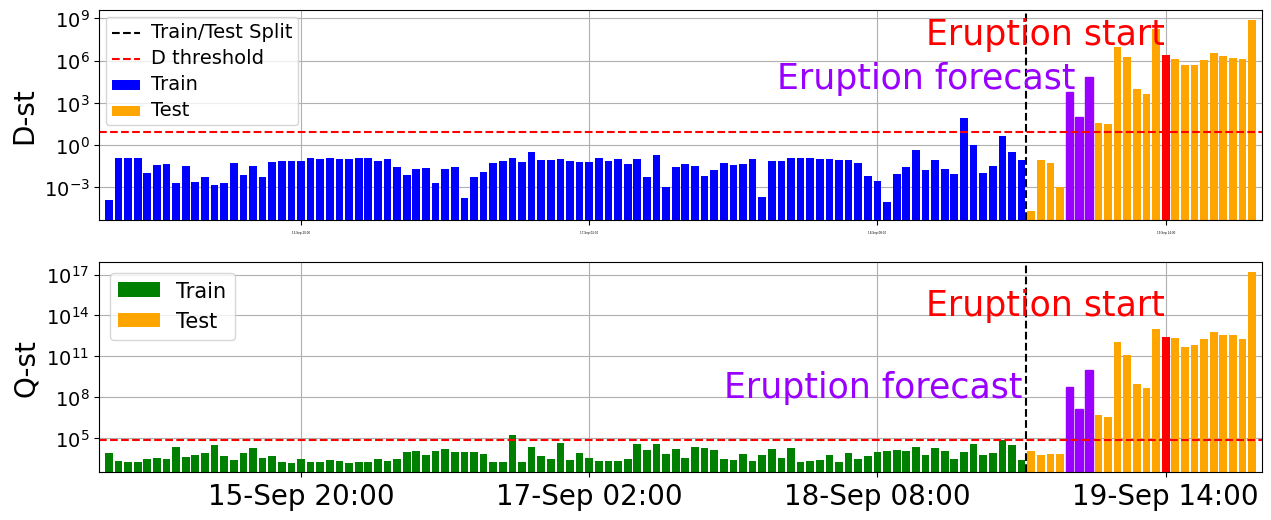

In [ ]:
import mspc_pca.mspc, mspc_pca.plot
PCs = 1


day_id = np.argmin(np.abs(timeUTC - np.datetime64(datetime(2021, 9, 19), 'm')))

D_train, Q_train, D_test, Q_test, threshold_D, threshold_Q = mspc_pca.mspc.DQ_tt(X[:day_id], X[day_id:], PCs,2, percentile_threshold=True, alpha=0.01)

fig, ax = plt.subplots(2,1, figsize = (15, 6))

ax = ax.tolist()

fig, ax = mspc_pca.plot.plot_DQ_tt(D_train, Q_train, D_test, Q_test, threshold_D, threshold_Q,
                                   logscale=True, event_index=[eruption_idx], 
                                    labels=None, plot_train=True, opacity=None, ax=ax)


n_bars = len(Q_train)+len(Q_test)

skip:int = len(timeUTC)//4
start = 20
locs = np.arange(0, n_bars)[start::skip]
timeUTC_label = timeUTC[start::skip]



date_formatter = mdates.DateFormatter('%d-%b %H:%M')
formatted_labels = [date_formatter(mdates.date2num(t)) for t in timeUTC_label]
ax[0].set_xticks(locs[:], labels=formatted_labels[:],fontsize=2);
ax[1].set_xticks(locs[:], labels=formatted_labels[:],fontsize=20);
ax[0].tick_params('y', labelsize=14)
ax[1].tick_params('y', labelsize=14)

ax[0].set_ylabel("D-st", fontsize = 20)
ax[0].set_title("")
legend = ax[0].get_legend()
for text in legend.get_texts():
    text.set_fontsize(16) 


ax[1].set_ylabel("Q-st", fontsize = 20)
ax[1].set_title("")
legend = ax[1].get_legend()
for text in legend.get_texts():
    text.set_fontsize(16) 

for axis in ax:
    axis.set_xlim(-1, n_bars)
    axis.grid(which='minor', alpha=0.5,)
    axis.set_axisbelow(True)

    # Leyendas
    legend = axis.get_legend()
    if legend:
        for text in legend.get_texts():
            text.set_fontsize(14)


forecast_id = eruption_idx - 10

color ="#069DDA" 
color ="#FD4FE0"
color ="#9900FF"

for i in range(3):
    ax[0].patches[forecast_id+i].set_color(color)
    ax[1].patches[forecast_id+i].set_color(color)

ax[0].text(85, 1.5e7, "Eruption start", color = "red", fontsize = 25)
ax[0].text(69.5, 1e4, "Eruption forecast", color = color, fontsize = 25)
ax[1].text(85, 1e14, "Eruption start", color = "red", fontsize = 25)
ax[1].text(64, 1e8, "Eruption forecast", color = color, fontsize = 25)


handles, labels = ax[1].get_legend_handles_labels()
index_to_remove = labels.index('Train/Test Split')
handles.pop(index_to_remove)
labels.pop(index_to_remove)
index_to_remove = labels.index('Q threshold')
handles.pop(index_to_remove)
labels.pop(index_to_remove)
ax[1].legend(handles, labels, fontsize=15)


### Testing U-square

In [40]:
from mspc_pca.mspc import train_params, U_squareda

ImportError: cannot import name 'train_params' from 'mspc_pca.mspc' (/home/TIC270/gsus/DigiVolcan/installation/miniconda3/envs/lafragua/lib/python3.12/site-packages/mspc_pca/mspc.py)

In [46]:
U_train = U[:day_id]

U_train, U[day_id:]

(array([-65.08899976, -65.1442098 , -65.14591659, -65.1404956 ,
        -65.1225843 , -65.12715137, -65.10288864, -65.07824629,
        -65.06832317, -65.0918156 , -64.97952296, -64.68447682,
        -64.90524903, -65.11496108, -65.08524235, -65.11653772,
        -64.82874428, -65.06408521, -65.12946503, -65.10386924,
        -65.12513199, -65.13669495, -65.14331985, -65.14013318,
        -65.12890179, -65.14207139, -65.14625595, -65.14740586,
        -65.14526412, -65.1267686 , -64.91620677, -65.05395776,
        -65.12312114, -65.08637201, -64.84577573, -64.45832521,
        -65.00335738, -64.64987457, -64.90358271, -64.97831234,
        -65.10573534, -65.11804413, -65.11294521, -65.13221903,
        -65.10467371, -65.13315829, -65.13192413, -65.13086497,
        -65.12885342, -65.13242629, -65.11981612, -65.13592244,
        -65.12682987, -65.13392171, -65.06479634, -65.15227915,
        -65.09047417, -64.98870394, -65.03194746, -64.77899731,
        -65.07557741, -65.08009841, -64.

ValueError: If 'ax' is provided, it must be a list or tuple of two matplotlib Axes objects.

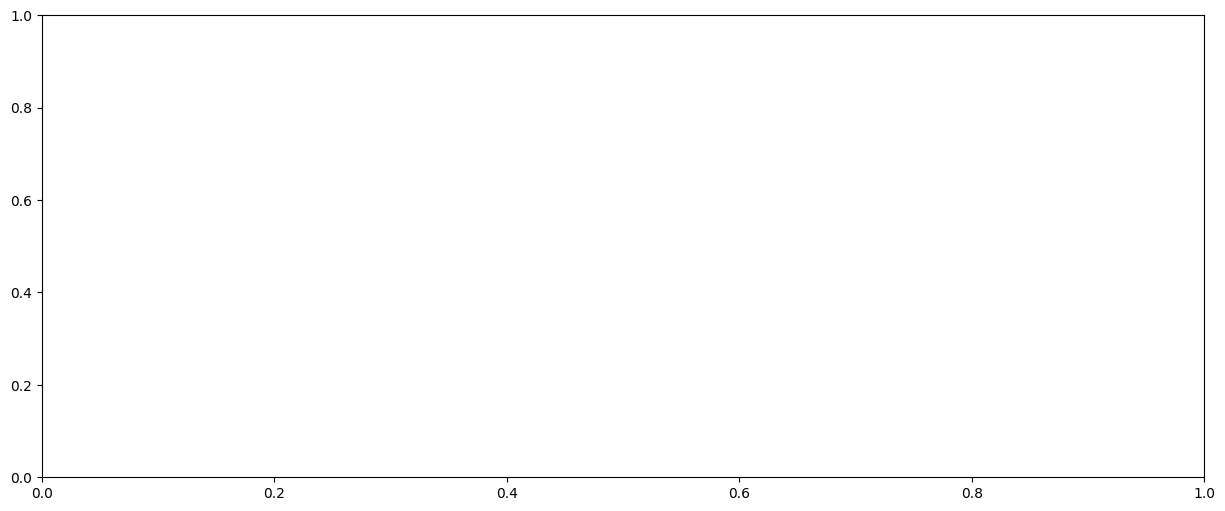

In [ ]:
from mspc_pca.plot import plot_U_tt
from mspc_pca import mspc


day_id = np.argmin(np.abs(timeUTC - np.datetime64(datetime(2021, 9, 19), 'm')))

mu, std, pca = mspc.train_params(X[:day_id], 2, 1)

scores = pca.fit_transform(X)

U = mspc.U_squared(scores, mu, std,)

fig,ax = plt.subplots(1,1, figsize=(15,3))

mspc_pca.plot.plot_U_tt(U[:day_id], U[day_id:], [None, .95], plot_train=True, logscale=True,ax=ax)

In [30]:
from mspc_pca.omeda import omeda
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches

# preprocessing = 1
# n_components = 2
logscale = False

# Frequency labels
n_freq = X.shape[1] // len(station_ids)
var_labels = np.linspace(0, sr // 2, n_freq)
var_label_ids = [i for i, label in enumerate(var_labels) if label % 10 == 0]
var_labels_str = [str(round(label, 4)) for label in var_labels if label % 10 == 0]
var_classes = []


pca.fit_transform(X)
loadings = pca.components_.T
dummy = - np.ones(len(X))
dummy[:day_id+5] = 1

dummy = -dummy

X_norm = X;


omeda_vec = omeda(testcs=X_norm, dummy=dummy, R=loadings, plot=False)


In [31]:
omeda_vec.shape, Sxxs.shape

((15015,), (5, 3, 1001, 120))

In [32]:
5* 3* 1001# 120

15015

In [33]:
freq

array([ 0.  ,  0.05,  0.1 , ..., 49.9 , 49.95, 50.  ], shape=(1001,))

Text(0.5125, 0.98, 'PPMA station')

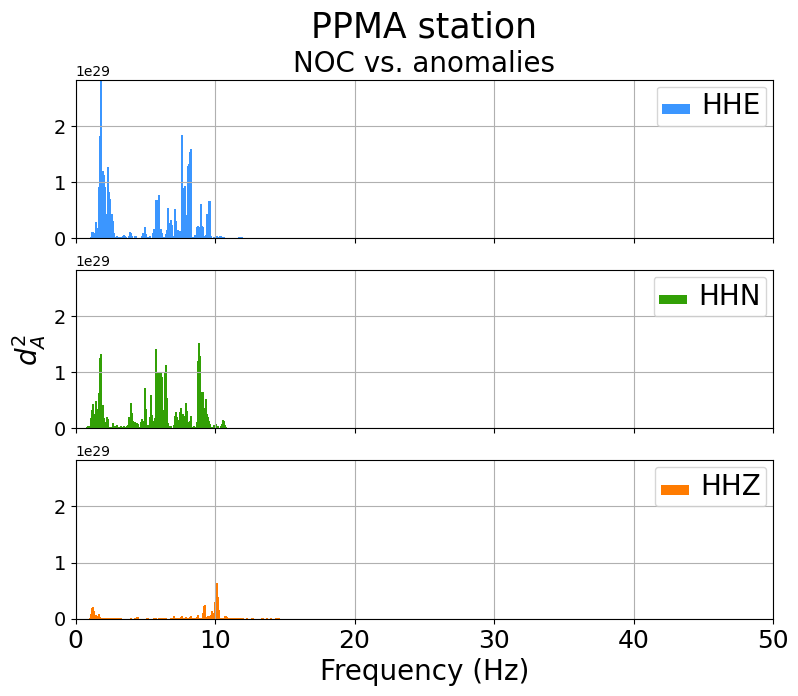

In [34]:
n_freqs = Sxxs.shape[2]
n_channels = Sxxs.shape[1]


colors = [ "#3B96FF","#32A006","#FF7B00",  ]

omeda_PPMA = omeda_vec[:n_freqs*n_channels*1]

vmin = np.min(omeda_PPMA)
vmax = np.max(omeda_PPMA)
fig, axes = plt.subplots(3,1, figsize =(9,7), sharex=True)
for i, ax in enumerate(axes):

    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xlim(0,50)
    ax.set_ylim(vmin, vmax)
    ax.bar(freq, omeda_PPMA[i*n_freqs:(i+1)*n_freqs], width=0.15, label = channels[i], color=colors[i])
    ax.grid(True)

    ax.legend()
    legend = ax.get_legend()
    if legend:
        for text in legend.get_texts():
            text.set_fontsize(20)

axes[1].set_ylabel('$d^2_A$', fontsize=20)
axes[-1].set_xlabel("Frequency (Hz)", fontsize = 20)
axes[0].set_title("NOC vs. anomalies", fontsize=20)

ax0_bbox = axes[0].get_position()

center_x_of_ax0 = (ax0_bbox.x0 + ax0_bbox.x1) / 2
fig.suptitle("PPMA station", fontsize=25,  x=center_x_of_ax0, y=ax0_bbox.y1 + 0.10, ha='center')

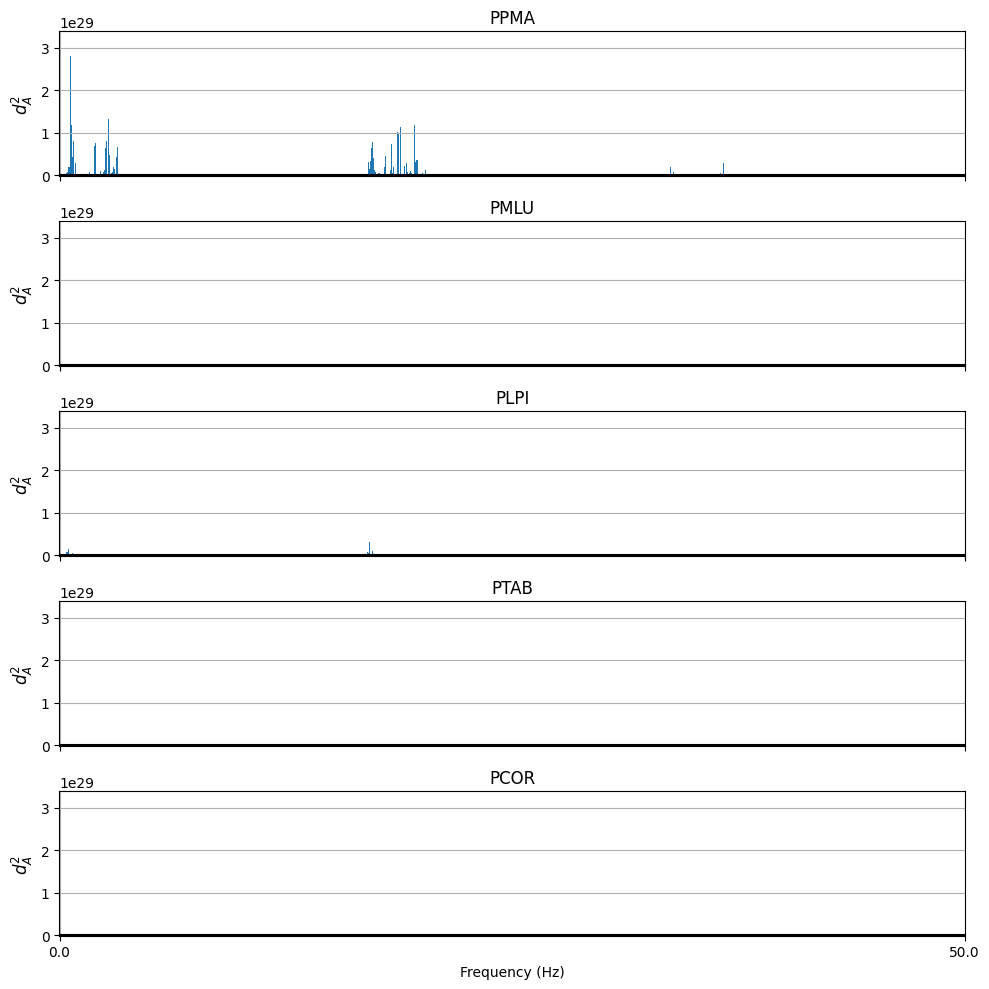

In [35]:

fig, ax = plt.subplots(len(station_ids),1, figsize=(10,10), sharex=True)
if type(ax) != np.ndarray: ax = [ax]

for i, station_id in enumerate(station_ids):
    x = np.arange(len(omeda_vec[i*n_freq : (i+1)*n_freq]))
    ax[i].set_xlim(np.min(x)-1, np.max(x)+1)

    # Handle coloring
    if var_classes:
        unique_classes = np.unique(var_classes)
        cmap = plt.get_cmap('tab10')
        colors = [cmap(i % 10) for i in range(len(unique_classes))]
        class_color_map = dict(zip(unique_classes, colors))
        bar_colors = [class_color_map[cls] for cls in var_classes]

        # Create legend
        patches = [mpatches.Patch(color=color, label=str(cls)) for cls, color in class_color_map.items()]
        ax[i].legend(handles=patches, prop={'size': 10})
    else:
        bar_colors = 'tab:blue'

    ax[i].bar(x, omeda_vec[i*n_freq : (i+1)*n_freq], color=bar_colors)

    ax[i].axhline(0, color='black', linewidth=1.5)  # X-axis

    # Handle variable labels
    if len(var_labels_str) > 0:
        ax[i].set_xticks(var_label_ids)
        label_lengths = [len(str(label)) for label in var_labels]
        rot = 90 if max(label_lengths) > 20 else 0  # rotate if labels are too long
        ax[i].set_xticklabels(var_labels_str, rotation=rot)
        ax[i].tick_params(axis='x', labelsize=10)

    ax[i].set_title(f"{eruption_stations[station_id]}")
    if i == len(station_ids) - 1:
        ax[i].set_xlabel("Frequency (Hz)")
    ax[i].set_ylabel('$d^2_A$', fontsize=12)
    ax[i].grid(True)
    # ax[i].set_xlim(0, )
    if logscale:
        ax[i].set_yscale("log")
        ax[i].set_ylim(1, 100 * max(omeda_vec))
    else:
        ax[i].set_ylim(0.8 * np.min(omeda_vec), 1.2 * np.max(omeda_vec))

plt.tight_layout()
plt.show()

In [36]:
np.max(omeda_vec)

np.float64(2.821514450572078e+29)

In [37]:
import obspy
st = obspy.read("/SCRATCH/TIC270/dvalesp/DigiVolCan/data/involcan/mseed/C7.PSAB..*.D.2025.21[0-1]")

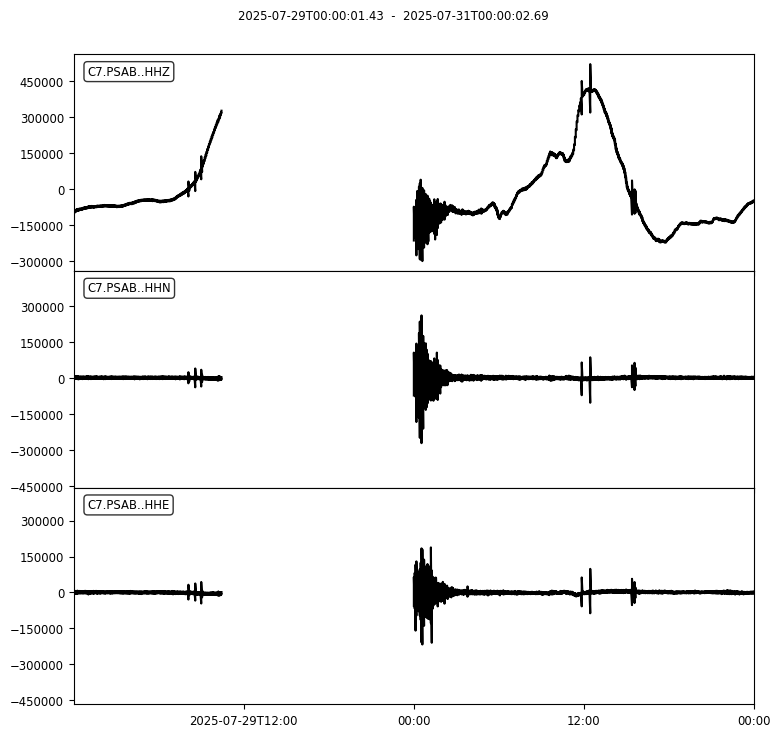

In [38]:
st.plot();

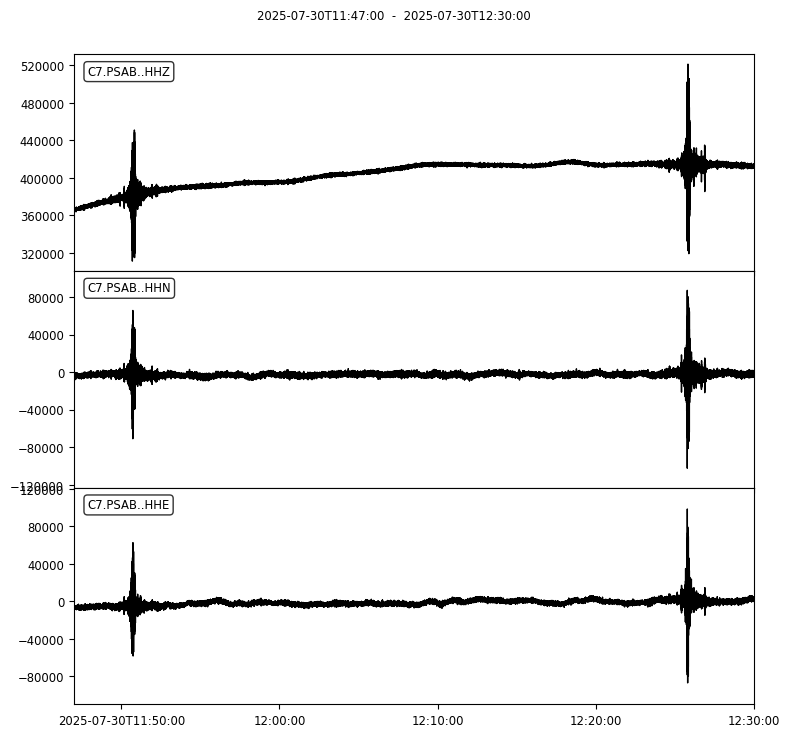

In [39]:
st = obspy.read("/SCRATCH/TIC270/dvalesp/DigiVolCan/data/involcan/mseed/C7.PSAB..*.D.2025.211")
from obspy import UTCDateTime
from datetime import datetime
st.plot(starttime=UTCDateTime(datetime(2025, 7, 30, 11, 47)), endtime=UTCDateTime(datetime(2025, 7, 30, 12, 30)));
